# 📊 Actualización incremental de artículos de PMC (full text)

En este notebook vamos a validar paso a paso la estrategia para **actualizaciones de artículos científicos** procedentes de PubMed Central (PMC).

PMC es un repositorio que contiene artículos científicos en formato completo (*full text*), identificados mediante un **PMCID**. A diferencia de PubMed (que contiene principalmente metadatos como título o abstract), PMC permite acceder al contenido completo de los artículos.

Para trabajar con estos datos, PMC proporciona un archivo llamado **`oa_file_list.csv`**, que actúa como un inventario de todos los artículos disponibles en el subconjunto Open Access.

Este archivo contiene, entre otros:
- Identificador del artículo (**PMCID**)
- Ruta de descarga del fichero
- Fecha de última actualización
- Licencia de uso

👉 Es importante entender que este archivo **no contiene el contenido del artículo**, sino información sobre dónde encontrarlo y si ha cambiado.


> **🎯 Objetivo**
>El objetivo de este notebook es implementar una estrategia básica para:
>
>- Detectar qué artículos son nuevos
>- Detectar qué artículos han sido modificados
>- Preparar el sistema para descargar y reprocesar solo esos artículos
>
> **⚙️ Estrategia**
> En este caso utilizaremos una estrategia **incremental**, basada en comparar el estado actual con el anterior. La idea clave es: 
> Usar el archivo `oa_file_list.csv` como fuente de verdad y detectar cambios entre ejecuciones.
>


## 🧩 Pasos que vamos a seguir

### 1. Cargar la file list de PMC
Descargaremos el archivo `oa_file_list.csv` y exploraremos su estructura para entender qué información contiene.


### 2. Seleccionar las columnas relevantes
Nos quedaremos únicamente con las columnas necesarias para nuestro sistema:
- PMCID (identificador del artículo)
- Ruta del fichero
- Fecha de última actualización
- Licencia


### 3. Crear un estado local
Guardaremos una copia local de la file list como referencia inicial (*baseline*).


### 4. Detectar cambios
En ejecuciones posteriores, compararemos:
- PMCID → para detectar artículos nuevos
- Fecha de actualización → para detectar modificaciones


### 5. Clasificar los artículos
Dividiremos los resultados en:
- 🟢 Nuevos
- 🟡 Actualizados
- 🔴 Eliminados (opcional)


### 6. Preparar la descarga
A partir de los artículos nuevos o modificados, generaremos una lista de ficheros que deberán descargarse en el siguiente paso del pipeline.



> **🚀 Qué NO vamos a hacer (de momento)**
>Para mantener el notebook sencillo, en esta fase **no vamos a**:
>- Descargar todos los artículos
>- Parsear XML
>- Generar embeddings
>
> En los notebooks validamos cada estapa de forma independiente.
>
>
> **💡 Idea clave**
>Este notebook permite 👉 **saber qué ha cambiado para no tener que procesarlo todo de nuevo**




In [1]:
import pandas as pd

url = "https://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_file_list.csv"

df = pd.read_csv(url)

print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

display(df.head())

Dimensiones: (7696529, 6)

Columnas:
['File', 'Article Citation', 'Accession ID', 'Last Updated (YYYY-MM-DD HH:MM:SS)', 'PMID', 'License']


,File,Article Citation,Accession ID,Last Updated (YYYY-MM-DD HH:MM:SS),PMID,License
0,oa_package/08/e0/PMC13900.tar.gz,Breast Cancer Res. 2001 Nov 2; 3(1):55-60,PMC13900,2025-06-04 10:25:31,11250746.0,NO-CC CODE
1,oa_package/b0/ac/PMC13901.tar.gz,Breast Cancer Res. 2001 Nov 9; 3(1):61-65,PMC13901,2019-11-05 11:56:12,11250747.0,NO-CC CODE
2,oa_package/f7/98/PMC13902.tar.gz,Breast Cancer Res. 2001 Nov 8; 3(1):66-75,PMC13902,2024-05-22 15:25:16,11250748.0,NO-CC CODE
3,oa_package/9c/7f/PMC13911.tar.gz,Breast Cancer Res. 2000 Nov 16; 2(1):59-63,PMC13911,2022-07-12 06:18:05,11056684.0,NO-CC CODE
4,oa_package/c6/fb/PMC13912.tar.gz,Breast Cancer Res. 2000 Dec 6; 2(1):64-72,PMC13912,2019-11-05 11:56:12,11400682.0,NO-CC CODE


> <br>     

> Para proyecto en producción:   
> 1.	Ejecutamos una vez (baseline)   
> 2.	Guardamos en Parquet   
> 3.	No volvemos a descargar completo, solo hacemos comparaciones incrementales.   
> <br>    

In [2]:
cols = df.columns
cols

Index(['File', 'Article Citation', 'Accession ID',
       'Last Updated (YYYY-MM-DD HH:MM:SS)', 'PMID', 'License'],
      dtype='str')

In [3]:
inventory = df[[
    'Accession ID',
    'PMID',
    'File',
    'Last Updated (YYYY-MM-DD HH:MM:SS)',
    'License'
]].copy()

In [4]:
inventory = inventory.rename(columns={
    'Accession ID': 'pmc_id',
    'PMID' : 'pm_id',
    'File': 'file',
    'Last Updated (YYYY-MM-DD HH:MM:SS)': 'last_updated',
    'License': 'license'
})

inventory['last_updated'] = pd.to_datetime(inventory['last_updated'])
inventory['pm_id'] = inventory['pm_id'].astype('Int64')

In [5]:
inventory.head()

,pmc_id,pm_id,file,last_updated,license
0,PMC13900,11250746,oa_package/08/e0/PMC13900.tar.gz,2025-06-04 10:25:31,NO-CC CODE
1,PMC13901,11250747,oa_package/b0/ac/PMC13901.tar.gz,2019-11-05 11:56:12,NO-CC CODE
2,PMC13902,11250748,oa_package/f7/98/PMC13902.tar.gz,2024-05-22 15:25:16,NO-CC CODE
3,PMC13911,11056684,oa_package/9c/7f/PMC13911.tar.gz,2022-07-12 06:18:05,NO-CC CODE
4,PMC13912,11400682,oa_package/c6/fb/PMC13912.tar.gz,2019-11-05 11:56:12,NO-CC CODE


In [ ]:
## guardamos archivo inventory para pruebas 
from pathlib import Path

path = Path("data/state")
path.mkdir(parents=True, exist_ok=True)


# inventory.to_csv(path / "pmc_oa_inventory.csv", index=False)
inventory.to_parquet("data/state/pmc_oa_inventory.parquet", index=False)

Con esta tabla podemos 
- detectar nuevos artículos → PMCID nuevo
- detectar cambios → last_updated distinto

Además tenemos los 2 identificadores con los que trabajamos: 

- **pm_id (PMID)**
Ej: 11250746
👉 Identifica el artículo en PubMed
👉 Es útil para cruzar con metadata (MeSH, abstract, etc.)
- **pmc_id (PMCID)**
Ej: PMC13900
👉 Identifica el artículo en PubMed Central
👉 Es el que necesitamos para trabajar con full text (contenido de la publicación)

⚠️ No siempre hay PMIDs (puede haber nulos por eso formato float en la columna)


## ✅ Conclusiones

### Fuente de estado: oa_file_list.csv
PMC publica y mantiene actualizado un archivo de inventario (oa_file_list.csv) con todos los artículos del subconjunto Open Access. Este archivo actúa como fuente de verdad del estado de PMC y es la base de nuestra estrategia de actualización incremental.

### Almacenamiento del estado local
Guardaremos una copia del inventario en data/state/pmc_oa_inventory.csv. Este archivo se sobreescribe en cada ejecución tras procesar los cambios, de forma que siempre refleje el último estado conocido del sistema.

### Detección de cambios
La comparación entre el inventario nuevo y el almacenado se realiza mediante un merge sobre pmc_id, lo que permite identificar en una sola operación:

- 🟢 Nuevos → pmc_id que aparece solo en el inventario nuevo
- 🟡 Actualizados → pmc_id presente en ambos con last_updated distinto
- 🔴 Eliminados → pmc_id que desaparece del inventario nuevo

### Ventaja de tener ambos identificadores
El oa_file_list.csv contiene tanto el pmc_id como el pm_id de cada artículo. Esto significa que cuando se detecta un cambio, disponemos directamente de:

- pm_id → para recuperar la metadata actualizada desde PubMed (abstract, MeSH, estado)
- pmc_id → para descargar el full text actualizado desde PMC

Sin necesidad de ninguna llamada adicional de conversión entre identificadores. El inventario ya hace de puente entre ambos sistemas.

### Filtrado por licencia
No todo el contenido Open Access de PMC es reutilizable. El oa_file_list.csv incluye la columna License, que determina bajo qué condiciones se puede procesar cada artículo.

Dado que nuestro sistema aplica transformaciones sobre el texto original (chunking, vectorización, combinación con un LLM en arquitectura RAG), las licencias con cláusula No Derivatives (ND) son incompatibles y quedan excluidas del corpus.

En un contexto académico no comercial, se incluyen las licencias CC BY, CC0, CC BY-SA, CC BY-NC y CC BY-NC-SA, que cubren aproximadamente el 82% del dataset Open Access. Las licencias NO-CC CODE, CC BY-ND y CC BY-NC-ND quedan excluidas.

Esto pone de manifiesto un principio importante: no todo dataset "open" es directamente usable para ML o sistemas RAG.

### Relación con la estrategia de PubMed
Esta estrategia es complementaria a la de pubmed_actualizations. Mientras que los update files de PubMed detectan cambios en metadatos y abstracts, el inventario de PMC detecta cambios en el contenido completo de los artículos. Ambos procesos pueden ejecutarse de forma independiente y coordinada.

## ⚖️ Licencias en PMC: qué podemos usar y qué no

En el archivo **oa_file_list.csv** aparece una columna llamada **License**, que indica bajo qué condiciones se puede utilizar cada artículo.

Esto es especialmente importante porque, aunque los artículos estén disponibles en PMC, **no todos se pueden reutilizar libremente**.

---

La licencia más común es **NO-CC CODE**. En estos casos el artículo es accesible para lectura, pero:

* ❌ No se puede reutilizar libremente
* ❌ No se puede usar para entrenamiento de modelos
* ❌ No se puede redistribuir

👉 Es el tipo que hemos visto en los primeros ejemplos.

---

### **Licencias Creative Commons (CC)**

Estas sí permiten reutilización, con distintas condiciones:

* ✅ **CC BY**: Permite uso, modificación, redistribución. Solo requiere atribución al autor.
* ✅ **CC BY-SA**: Igual que CC BY, pero las obras derivadas deben mantener la misma licencia.
* ⚠️ **CC BY-NC**: Permite reutilización **solo para uso no comercial**.
* ❌ **CC BY-ND**: No permite modificar el contenido.

<br>

> **⚠️ Por qué es importante en este proyecto**
>
> Nuestro objetivo es descargar artículos, procesar texto completo y generar embeddings. Para hacer esto de forma correcta solo deberíamos usar artículos con licencias que permitan reutilización.
>  


#### **🎯 Decisión en el pipeline**

Por defecto, se recomienda:
* ❌ Excluir: NO-CC CODE
* ✅ Incluir: licencias tipo CC BY, CC BY-SA, etc.

<br>

>💡 **Idea clave**
>- No todo lo que está en PMC se puede usar libremente   
>- La licencia determina si puedes procesar, almacenar o reutilizar el contenido
>


### Análisis de distribución de las licencias

In [ ]:
inventory = pd.read_parquet("data/state/pmc_oa_inventory.parquet")

In [10]:
# Contar cuántos artículos hay por tipo de licencia
license_counts = inventory['license'].value_counts(dropna=False)

# Mostrar resultados
print("Distribución de licencias:")
display(pd.DataFrame(license_counts))

# Convertir a porcentaje (muy útil para la memoria)
license_percent = (license_counts / len(inventory)) * 100

print("\nDistribución (%) de licencias:")
display(pd.DataFrame(license_percent.round(2)))

Distribución de licencias:


,count
license,
CC BY,4938337
CC BY-NC-ND,968901
CC BY-NC,928794
NO-CC CODE,403180
CC BY-NC-SA,296591
CC0,147497
CC BY-ND,11260
CC BY-SA,1969



Distribución (%) de licencias:


,count
license,
CC BY,64.16
CC BY-NC-ND,12.59
CC BY-NC,12.07
NO-CC CODE,5.24
CC BY-NC-SA,3.85
CC0,1.92
CC BY-ND,0.15
CC BY-SA,0.03


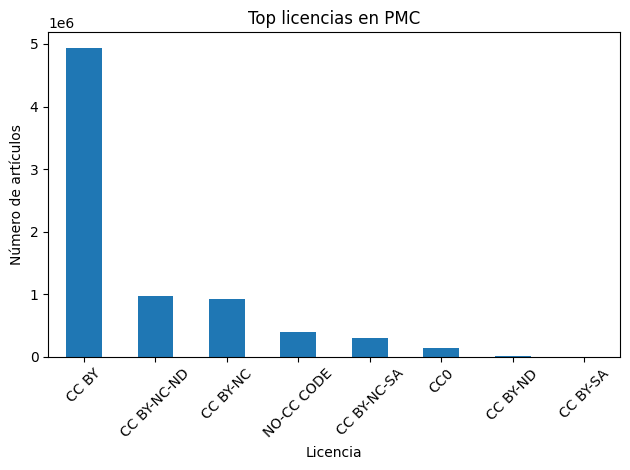

In [11]:
import matplotlib.pyplot as plt

license_counts.head(10).plot(kind='bar')

plt.title("Top licencias en PMC")
plt.xlabel("Licencia")
plt.ylabel("Número de artículos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📊 Insight: reutilización de licencias en contexto académico

El análisis de la distribución de licencias en el subconjunto Open Access de PMC muestra que una gran parte del corpus es utilizable en un contexto académico para tareas de procesamiento de lenguaje natural.

En concreto:

- El **64.16% de los artículos** están bajo licencia **CC BY**, que permite uso, modificación y redistribución sin restricciones comerciales, siempre que se proporcione atribución.
- Un **1.92% adicional** corresponde a **CC0 (dominio público)**, lo que implica ausencia total de restricciones.
- Licencias como **CC BY-SA** (0.03%) también permiten reutilización, aunque requieren mantener la misma licencia en trabajos derivados.

👉 En conjunto, aproximadamente un **66% del corpus es completamente reutilizable sin restricciones**, incluso en entornos comerciales.

Además:

- Un **15.92% adicional** (CC BY-NC y CC BY-NC-SA) permite reutilización **en contextos no comerciales**, como es el caso de este proyecto académico.
  
👉 Esto eleva el volumen de datos potencialmente utilizables hasta aproximadamente un **82% del dataset**.

Por otro lado:

- Un **18% del corpus** presenta restricciones incompatibles con el procesamiento del texto, como `NO-CC CODE` o licencias con cláusula *No Derivatives*, que impiden la modificación del contenido.

---

### 🧠 Implicación para el sistema

Dado que este proyecto se desarrolla en un **contexto académico**, se adopta la siguiente estrategia:

- ✅ Incluir:
  - CC BY
  - CC0
  - CC BY-SA
  - CC BY-NC
  - CC BY-NC-SA

- ❌ Excluir:
  - NO-CC CODE
  - CC BY-ND
  - CC BY-NC-ND

> 
> Las licencias con cláusula No Derivatives (ND) no permiten la transformación del contenido original.     
> Dado que nuestro sistema se compone de un RAG ( que incluye fragmentación del texto, vetorización y combinación del conjunto de la información extraída con un llm) estas > licencias se consideran incompatibles con el sistema propuesto y se excluyen del corpus.  
> **No todo dataset “open” es usable para ML** 

Esta decisión permite maximizar el volumen de datos disponibles para el análisis, manteniendo la coherencia con las restricciones legales de reutilización en un entorno no comercial.